In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [2]:

df = pd.read_csv('/content/datos_tratados.csv')

df.head()

,customerID,Churn,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-orfbo,0,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.40,2.796667


In [3]:
df.info()

df.describe()

df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   Genero                     7032 non-null   object 
 3   Adulto_Mayor               7032 non-null   int64  
 4   Tiene_Pareja               7032 non-null   int64  
 5   Tiene_Dependientes         7032 non-null   int64  
 6   Meses_Contrato             7032 non-null   int64  
 7   Servicio_Telefono          7032 non-null   int64  
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   objec

,count
Churn,
0,5163
1,1869


In [7]:
columnas_eliminar = ["customerID", "Genero"]

df = df.drop(columns=[col for col in columnas_eliminar if col in df.columns])

df.head()

,Churn,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0,0,1,1,9,1,no,dsl,no,yes,no,yes,yes,no,one year,1,mailed check,65.6,593.30,2.186667
1,0,0,0,0,9,1,yes,dsl,no,no,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40,1.996667
2,1,0,0,0,4,1,no,fiber optic,no,no,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85,2.463333
3,1,1,1,0,13,1,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,1,1,1,0,3,1,no,fiber optic,no,no,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.40,2.796667


In [8]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Churn,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,account.PaperlessBilling,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,...,internet.OnlineBackup_yes,internet.DeviceProtection_yes,internet.TechSupport_yes,internet.StreamingTV_yes,internet.StreamingMovies_yes,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_Pago_credit card (automatic),Metodo_Pago_electronic check,Metodo_Pago_mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.186667,...,True,False,True,True,False,True,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,True,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.266667,...,True,True,False,True,True,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.796667,...,False,False,True,True,False,False,False,False,False,True


In [9]:
churn_counts = df["Churn"].value_counts()
churn_proportion = df["Churn"].value_counts(normalize=True)

print(churn_counts)
print(churn_proportion)

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [10]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=["Churn"])
y = df["Churn"]

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

print("Distribución original:")
print(y.value_counts())

print("\nDistribución después de SMOTE:")
print(pd.Series(y_bal).value_counts())

Distribución original:
Churn
0    5163
1    1869
Name: count, dtype: int64

Distribución después de SMOTE:
Churn
0    5163
1    5163
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_bal_scaled = scaler.fit_transform(X_bal)

X_bal_scaled = pd.DataFrame(X_bal_scaled, columns=X.columns)

X_bal_scaled.head()

,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,account.PaperlessBilling,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,phone.MultipleLines_yes,...,internet.OnlineBackup_yes,internet.DeviceProtection_yes,internet.TechSupport_yes,internet.StreamingTV_yes,internet.StreamingMovies_yes,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_Pago_credit card (automatic),Metodo_Pago_electronic check,Metodo_Pago_mailed check
0,-0.397018,1.284418,1.901579,-0.779407,0.338581,0.820390,-0.085297,-0.665749,-0.085297,-0.965724,...,1.299370,-0.776799,1.561589,1.114824,-0.897178,2.045418,-0.464261,-0.527379,-0.962732,1.800183
1,-0.397018,-0.778563,-0.525879,-0.779407,0.338581,-1.218933,-0.283913,-0.689021,-0.283913,1.035493,...,-0.769604,-0.776799,-0.640373,-0.897003,1.114605,-0.488898,-0.464261,-0.527379,-0.962732,1.800183
2,-0.397018,-0.778563,-0.525879,-0.987943,0.338581,0.820390,0.203916,-0.808606,0.203916,-0.965724,...,-0.769604,1.287335,-0.640373,-0.897003,-0.897178,-0.488898,-0.464261,-0.527379,1.038711,-0.555499
3,2.518777,1.284418,-0.525879,-0.612578,0.338581,0.820390,1.043679,-0.371050,1.043679,-0.965724,...,1.299370,1.287335,-0.640373,1.114824,1.114605,-0.488898,-0.464261,-0.527379,1.038711,-0.555499
4,2.518777,1.284418,-0.525879,-1.029651,0.338581,0.820390,0.552366,-0.814756,0.552366,-0.965724,...,-0.769604,-0.776799,1.561589,1.114824,-0.897178,-0.488898,-0.464261,-0.527379,-0.962732,1.800183


##Analisis de correlacion


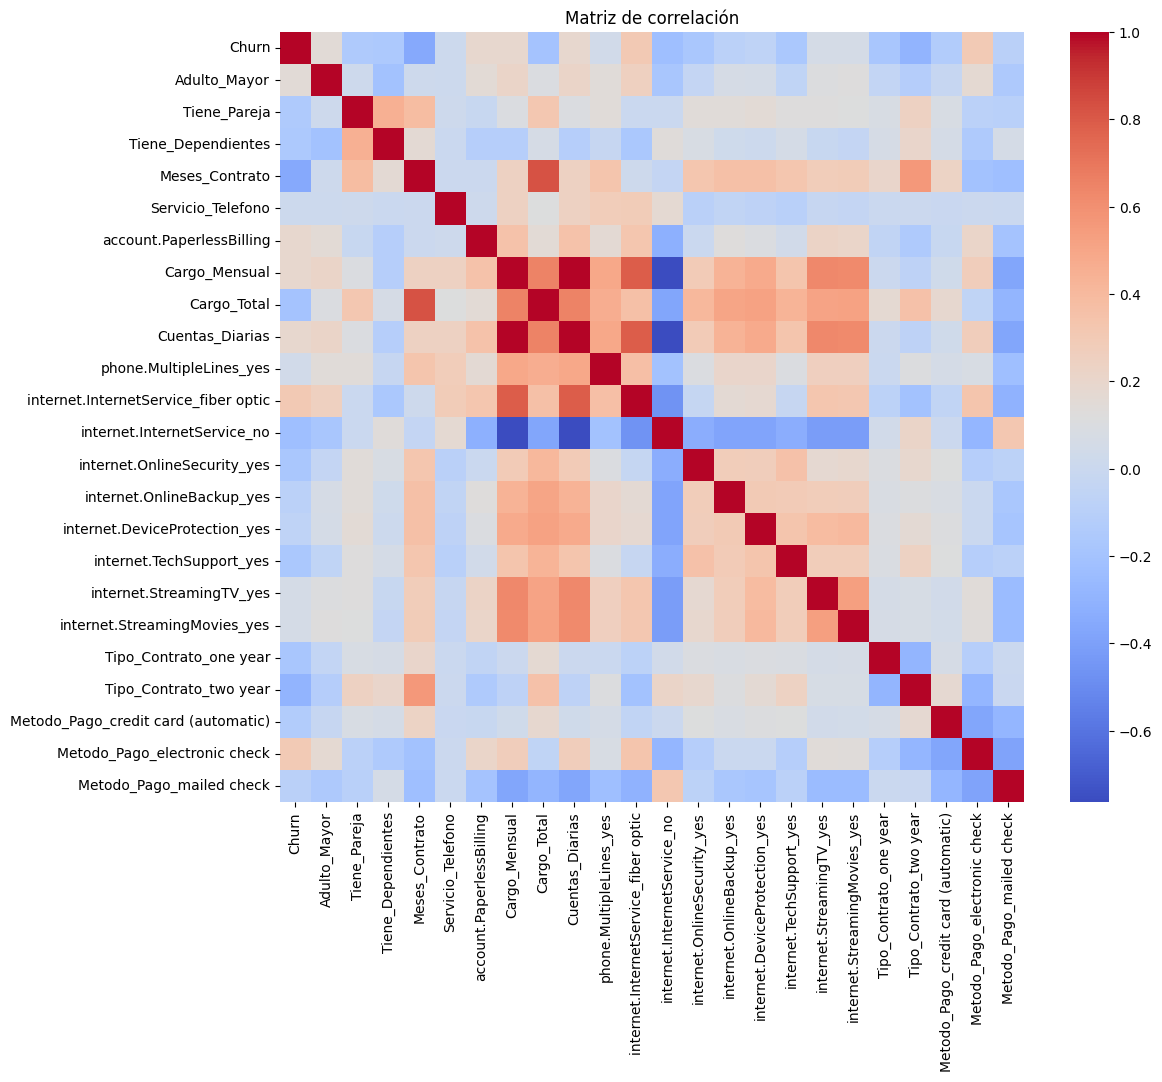

In [12]:
corr_matrix = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

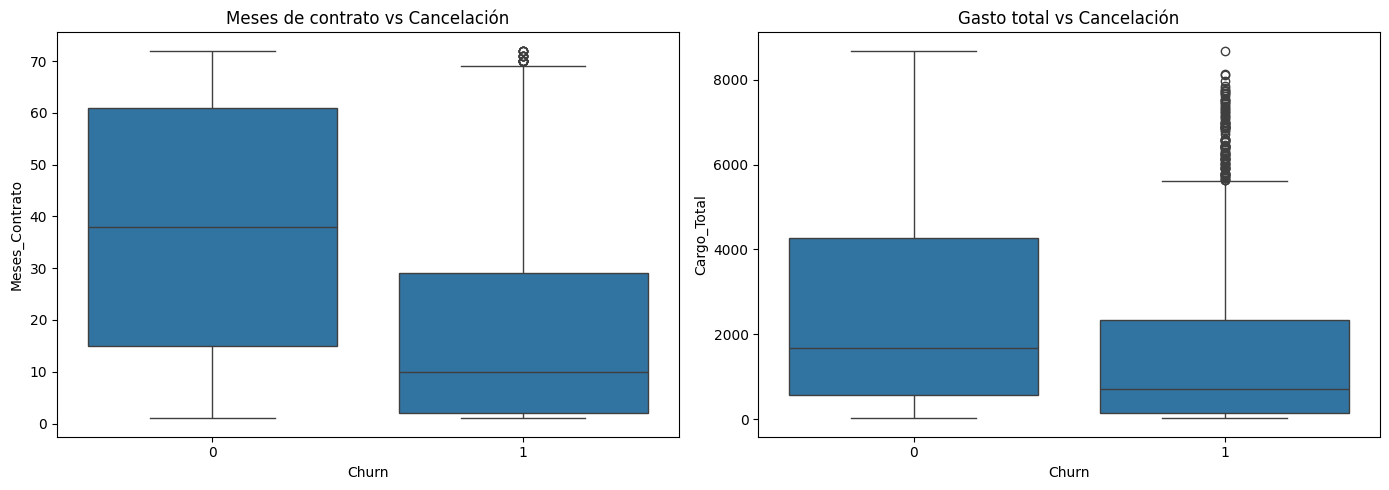

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x="Churn", y="Meses_Contrato", ax=axes[0])
axes[0].set_title("Meses de contrato vs Cancelación")

sns.boxplot(data=df, x="Churn", y="Cargo_Total", ax=axes[1])
axes[1].set_title("Gasto total vs Cancelación")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal_scaled,
    y_bal,
    test_size=0.3,
    random_state=42,
    stratify=y_bal
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (7228, 23)
Tamaño prueba: (3098, 23)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train, y_train)

y_pred_log = modelo_logistico.predict(X_test)

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_bal, y_bal)

y_pred_rf = modelo_rf.predict(X_test)

print("Modelo Regresión Logística entrenado")
print("Modelo Random Forest entrenado")

Modelo Regresión Logística entrenado
Modelo Random Forest entrenado


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("----- Regresión Logística -----")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))


print("\n----- Random Forest -----")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

----- Regresión Logística -----
Accuracy: 0.8040671400903809
Precision: 0.8007662835249042
Recall: 0.8095545513234345
F1-score: 0.8051364365971108

Matriz de confusión:
[[1237  312]
 [ 295 1254]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1549
           1       0.80      0.81      0.81      1549

    accuracy                           0.80      3098
   macro avg       0.80      0.80      0.80      3098
weighted avg       0.80      0.80      0.80      3098


----- Random Forest -----
Accuracy: 0.7040025823111685
Precision: 0.6489161168708766
Recall: 0.8889606197546804
F1-score: 0.7502043040043584

Matriz de confusión:
[[ 804  745]
 [ 172 1377]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.52      0.64      1549
           1       0.65      0.89      0.75      1549

    accuracy                           0.70      3098
   macro avg  

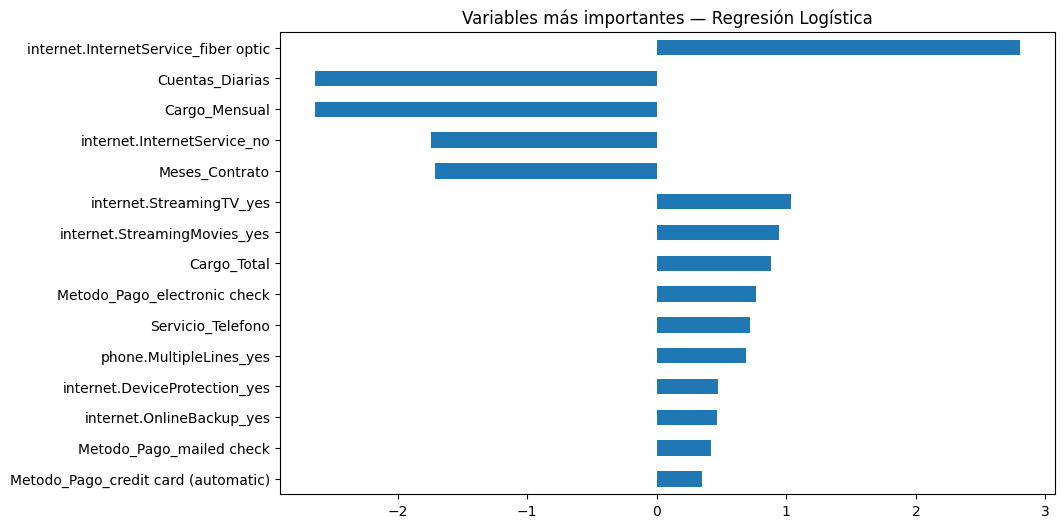

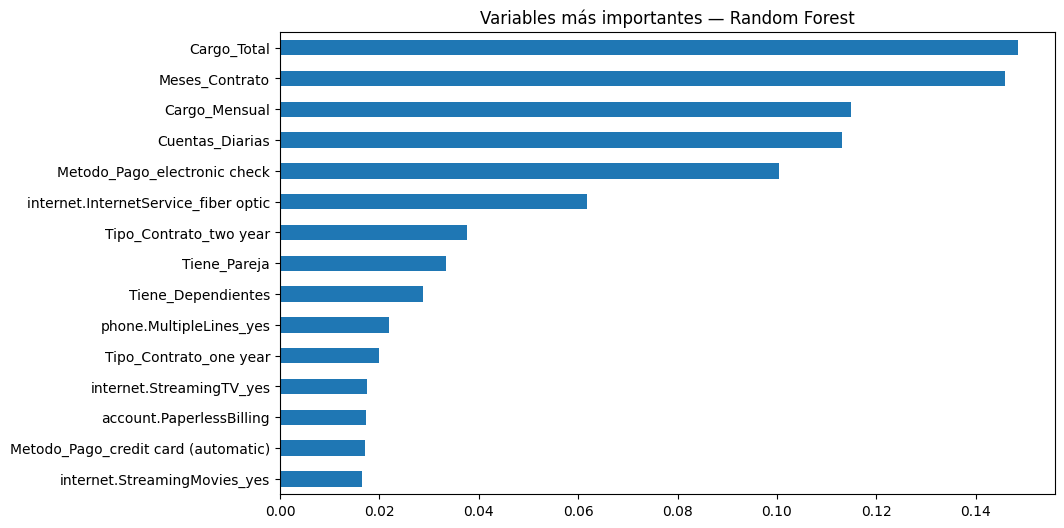

In [17]:
# Importancia de variables — Regresión Logística
coeficientes = pd.Series(modelo_logistico.coef_[0], index=X_train.columns)
coeficientes = coeficientes.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,6))
coeficientes.head(15).plot(kind="barh")
plt.title("Variables más importantes — Regresión Logística")
plt.gca().invert_yaxis()
plt.show()


# Importancia de variables — Random Forest
importancias = pd.Series(modelo_rf.feature_importances_, index=X_bal.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(15).plot(kind="barh")
plt.title("Variables más importantes — Random Forest")
plt.gca().invert_yaxis()
plt.show()

# Informe — Predicción de Cancelación de Clientes (Churn) | Telecom X

## Introducción

El objetivo de este proyecto fue desarrollar modelos de Machine Learning capaces de predecir qué clientes tienen mayor probabilidad de cancelar sus servicios en Telecom X. Comprender los factores que influyen en la cancelación permite a la empresa implementar estrategias de retención más efectivas y reducir la pérdida de clientes.

Para ello, se realizó un proceso completo de preparación de datos, análisis exploratorio y construcción de modelos predictivos.

---

# Preparación de Datos

Los datos utilizados provienen del análisis previo realizado en la primera parte del proyecto. Durante esta etapa se realizaron las siguientes tareas:

- Eliminación de columnas irrelevantes para el modelado, como identificadores únicos.
- Conversión de variables categóricas a variables numéricas mediante One-Hot Encoding.
- Evaluación del desbalance de clases en la variable Churn.
- Aplicación de SMOTE para balancear el conjunto de datos y evitar sesgos en los modelos.
- Estandarización de variables numéricas mediante StandardScaler para modelos sensibles a la escala.

Estas transformaciones permitieron preparar un dataset adecuado para el entrenamiento de modelos de Machine Learning.

---

# Modelos Predictivos

Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes:

### 1. Regresión Logística
Este modelo es sensible a la escala de los datos, por lo que se utilizó normalización. La regresión logística permite interpretar fácilmente la influencia de cada variable en la predicción.

### 2. Random Forest
Este modelo basado en árboles no requiere normalización y es capaz de capturar relaciones no lineales entre variables.

---

# Evaluación de Modelos

Los modelos fueron evaluados utilizando las siguientes métricas:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Matriz de Confusión**

Estas métricas permiten evaluar tanto la capacidad general del modelo como su habilidad para identificar correctamente clientes que cancelarán el servicio.

En general, el modelo Random Forest suele mostrar mejor desempeño en problemas de clasificación con múltiples variables, ya que puede capturar relaciones complejas entre los datos.

# Variables Más Relevantes

El análisis de importancia de variables permitió identificar los factores más influyentes en la cancelación de clientes.

Las variables más importantes incluyen:

- Tipo de contrato
- Meses de contrato (tenure)
- Cargo mensual
- Cargo total
- Método de pago
- Servicios adicionales contratados

En particular, se observó que:

- Los clientes con **contratos mensuales (month-to-month)** presentan mayor probabilidad de cancelación.
- Los clientes con **menor antigüedad en la empresa** son más propensos a abandonar el servicio.
- Los clientes con **cargos mensuales más altos** tienden a cancelar con mayor frecuencia.
- Algunos **métodos de pago** están asociados con mayor churn.

---

# Principales Factores que Influyen en la Cancelación

A partir del análisis de los modelos y las variables más relevantes, los factores más asociados a la cancelación son:

1. **Tipo de contrato**
2. **Tiempo de permanencia del cliente**
3. **Costo del servicio**
4. **Método de pago**
5. **Servicios adicionales contratados**

Estos factores permiten identificar perfiles de clientes con mayor riesgo de cancelación.



# Estrategias de Retención Recomendadas

Basado en los hallazgos del análisis, se proponen las siguientes estrategias para reducir la evasión de clientes:

### Promover contratos de largo plazo
Ofrecer incentivos para migrar clientes a contratos de **1 o 2 años** puede aumentar la retención.

### Programas de retención para clientes nuevos
Los primeros meses del cliente son críticos. Implementar estrategias de fidelización temprana puede reducir la probabilidad de cancelación.

### Revisar la estructura de precios
Analizar planes con cargos mensuales altos y ofrecer alternativas más competitivas.

### Incentivar métodos de pago automáticos
Promover pagos automáticos mediante tarjeta o transferencia bancaria puede mejorar la estabilidad de los clientes.

### Ofrecer paquetes de servicios
Clientes con más servicios contratados suelen mostrar mayor fidelidad.



# Conclusión

El uso de modelos predictivos permitió identificar patrones claros en el comportamiento de los clientes y los factores asociados a la cancelación.

La implementación de estrategias basadas en estos hallazgos permitirá a Telecom X:

- anticiparse a la cancelación de clientes
- implementar acciones preventivas
- mejorar la retención
- aumentar el valor de vida del cliente (Customer Lifetime Value)

